In [1]:
import pandas as pd

# Đọc file CSV đã được tiền xử lý
csv_path = "cleaned_order_history.csv"
df = pd.read_csv(csv_path)

# Hiển thị các cột để kiểm tra cấu trúc
df.columns


Index(['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID',
       'Order Placed At', 'Order Status', 'Delivery', 'Distance',
       'Items in order', 'Discount construct', 'Bill subtotal',
       'Packaging charges', 'Restaurant discount (Promo)',
       'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount',
       'Brand pack discount', 'Total', 'Rating',
       'Cancellation / Rejection reason',
       'Restaurant compensation (Cancellation)', 'KPT duration (minutes)',
       'Rider wait time (minutes)', 'Order Ready Marked',
       'Customer complaint tag', 'Customer ID'],
      dtype='object')

In [2]:
# Lọc các dòng có 'Order Market Value' là "Incorrected"
incorrected_rows = df[df['Order Ready Marked'] == "Incorrectly"]

# In ra kết quả
print(incorrected_rows)

print(f"Số dòng có Order Ready Marked là 'incorrectly': {len(incorrected_rows)}")


       Restaurant ID    Restaurant name                  Subzone       City  \
6           20320607              Swaad                 Sector 4  Delhi NCR   
18          20320607              Swaad                 Sector 4  Delhi NCR   
26          20320607              Swaad                 Sector 4  Delhi NCR   
32          20320607              Swaad                 Sector 4  Delhi NCR   
33          20320607              Swaad                 Sector 4  Delhi NCR   
...              ...                ...                      ...        ...   
21255       21143186  Tandoori Junction  Greater Kailash 2 (GK2)  Delhi NCR   
21259       21145152  Tandoori Junction                 Sector 4  Delhi NCR   
21292       21309083              Swaad               Sector 135  Delhi NCR   
21297       21309083              Swaad               Sector 135  Delhi NCR   
21318       21523055    Masala Junction                 Sector 4  Delhi NCR   

         Order ID      Order Placed At Order Status

0th percentile: 0.20 phút
10th percentile: 3.40 phút
25th percentile: 4.50 phút
50th percentile: 7.20 phút
70th percentile: 10.10 phút
90th percentile: 15.50 phút
99th percentile: 26.54 phút


C:\Users\krizb\AppData\Local\Temp\ipykernel_19616\1096236824.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incorrect_ready['Wait Time Group'] = pd.cut(


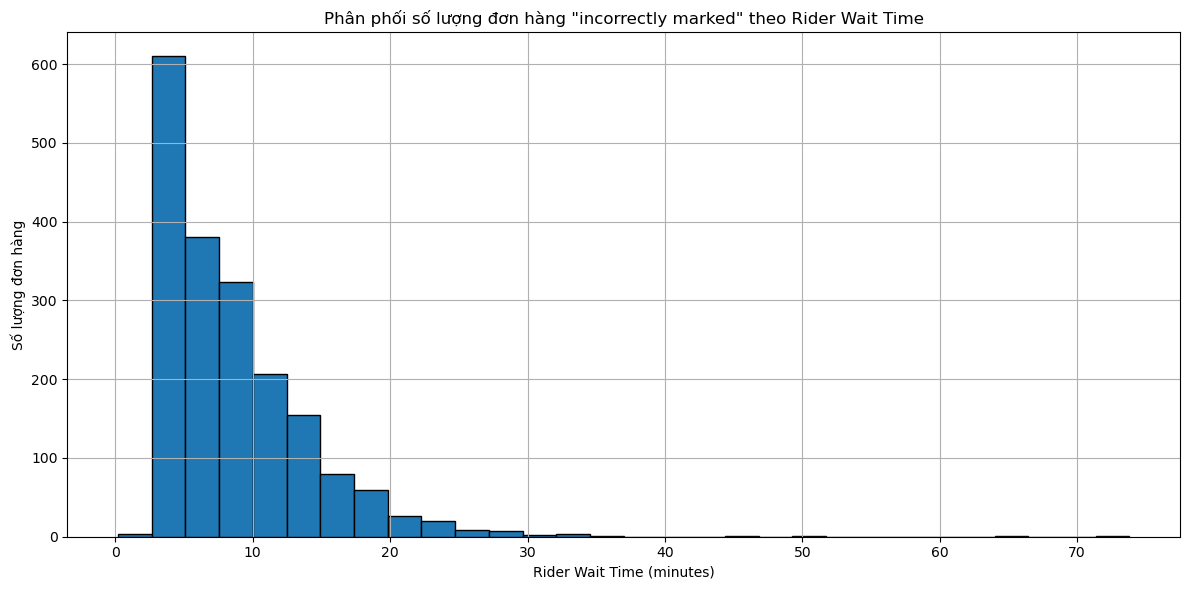

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Không dùng train-test, dùng toàn bộ dữ liệu có Order Ready Marked = 'incorrectly'
df_incorrect_ready = df[df['Order Ready Marked'].str.lower() == 'incorrectly']

# Tính phân vị rider wait time
rider_wait_times = df_incorrect_ready['Rider wait time (minutes)'].dropna()
percentiles = [0, 10, 25, 50, 70, 90, 99]
percentile_values = rider_wait_times.quantile([p/100 for p in percentiles])

# Hiển thị kết quả
for p, value in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {value:.2f} phút")

# Tạo DataFrame chứa phân vị
custom_percentile_df = percentile_values.reset_index()
custom_percentile_df.columns = ['Percentile', 'Rider Wait Time (minutes)']

# Loại trùng và đảm bảo tăng dần
bins = sorted(set(custom_percentile_df['Rider Wait Time (minutes)'].tolist()))

# Tạo labels tương ứng với số khoảng (bins - 1)
labels = [f"{percentiles[i]}-{percentiles[i+1]}%" for i in range(len(bins) - 1)]

# Cắt dữ liệu thành nhóm
df_incorrect_ready['Wait Time Group'] = pd.cut(
    df_incorrect_ready['Rider wait time (minutes)'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Đếm số lượng đơn hàng theo từng nhóm
group_counts = df_incorrect_ready['Wait Time Group'].value_counts().sort_index()

# Tính midpoint các khoảng để vẽ biểu đồ
mid_points = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]

# Vẽ biểu đồ phân bố dạng histogram theo Rider wait time
plt.figure(figsize=(12, 6))
plt.hist(incorrected_rows['Rider wait time (minutes)'].dropna(), bins=30, edgecolor='black')
plt.title('Phân phối số lượng đơn hàng "incorrectly marked" theo Rider Wait Time')
plt.xlabel('Rider Wait Time (minutes)')
plt.ylabel('Số lượng đơn hàng')
plt.grid(True)
plt.tight_layout()
plt.show()


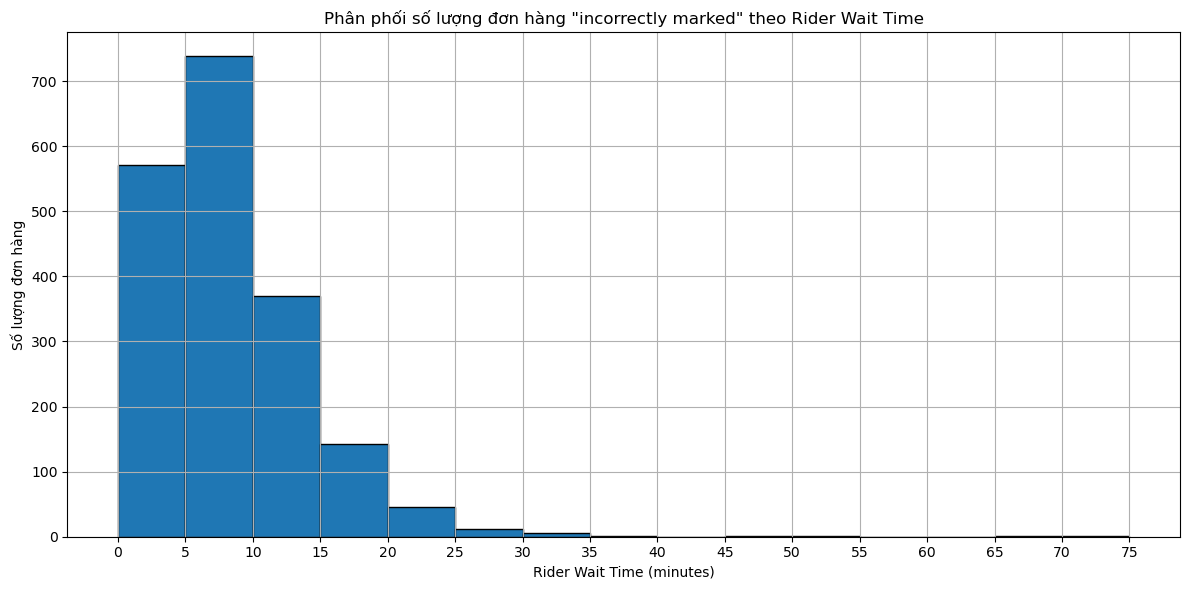

In [5]:
import numpy as np

# Tạo bins mỗi 5 phút
max_time = int(rider_wait_times.max()) + 5
bins = np.arange(0, max_time + 1, 5)  # ví dụ: 0, 5, 10, ..., max

# Vẽ histogram
plt.figure(figsize=(12, 6))
plt.hist(rider_wait_times, bins=bins, edgecolor='black')
plt.title('Phân phối số lượng đơn hàng "incorrectly marked" theo Rider Wait Time')
plt.xlabel('Rider Wait Time (minutes)')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(bins)  # Set nhãn trục x đúng mỗi 5 phút
plt.grid(True)
plt.tight_layout()
plt.show()


#### Do phần cột rider wait từ 5-10' có hơn 700 đơn tới cột 10-15' thì giảm xuống còn chưa tới 400 đơn, nen xác định ngưỡng mà tài xế có thể chấp nhận chờ tại nhà hàng được là 10'
#### Có bài báo chính sách Zomato giảm thời gian chờ của tài xế khi chờ đồ ăn tại nhà hàng từ 15' xuống 10': https://www.newsclick.in/zomato-workers-win-benefits-4-day-strike-thiruvananthapuram%C2%A0#:~:text=The%20company%20has%20also%20agreed,will%20also%20be%20activated%20immediately: "Việc hạ ngưỡng từ 15 xuống 10 phút cho thấy công ty thừa nhận chờ quá 10 phút đã là bất hợp lý nếu không có bồi thường".
#### Chia sẻ thực tế từ tài xế Zomato: "Nhiều tài xế Zomato bất bình vì không được trả phụ cấp chờ. Tại Kerala (Ấn Độ), các tài xế Zomato đình công phản đối việc công ty bỏ khoản tiền chờ, cho biết dù họ chờ tới 1 giờ ở nhà hàng cũng không được trả thêm". https://keralakaumudi.com/en/news/news.php?id=1273649&u=zomato-delivery-agents-on-strike-in-kottayam#:~:text=%27We%20have%20informed%20the%20company,strike%2C%27%20said%20the%20workers%20said 


In [6]:
filtered_rows = incorrected_rows[incorrected_rows["Rider wait time (minutes)"] > 10]

# Tạo hàm đếm số dòng thỏa điều kiện
def count_filtered_rows():
    return len(filtered_rows)

# In ra kết quả
print("Số dòng có 'Rider wait time (minutes)' > 10 trong 'incorrected_rows':", count_filtered_rows())

filtered_rows.to_csv("filtered_wait_time_7_plus.csv", index=False)


Số dòng có 'Rider wait time (minutes)' > 10 trong 'incorrected_rows': 572


In [7]:
# Tính tỷ lệ giữa số dòng filtered_rows và incorrected_rows
ratio = len(filtered_rows) / len(incorrected_rows)

# Chuyển tỷ lệ thành phần trăm, làm tròn 2 chữ số
percentage = round(ratio * 100, 2)
print("Tỷ lệ giữa những đơn hàng incorrectly có rider wait time > 10 phút và tổng số đơn hàng incorrectly: ", percentage)



Tỷ lệ giữa những đơn hàng incorrectly có rider wait time > 10 phút và tổng số đơn hàng incorrectly:  30.18


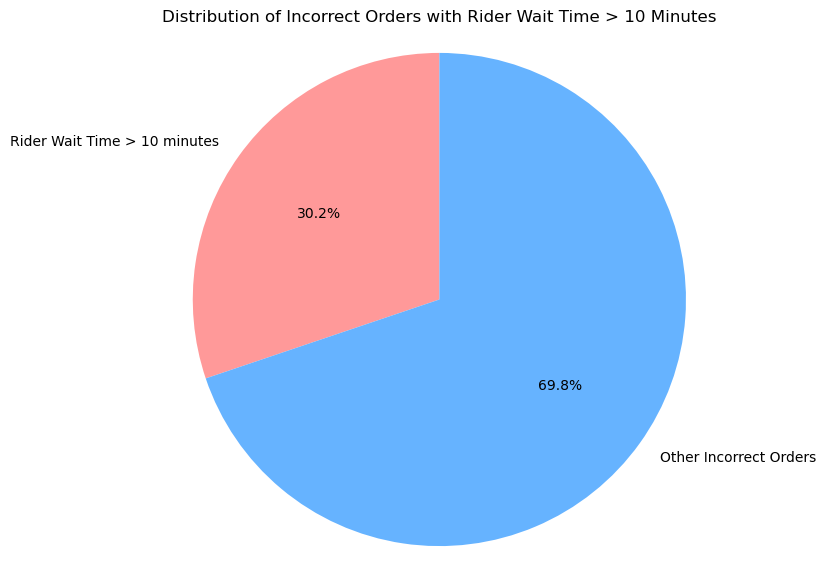

In [10]:
import matplotlib.pyplot as plt


# Create a pie chart to compare incorrectly orders with rider wait time > 7 minutes versus total incorrect orders
sizes = [len(filtered_rows), len(incorrected_rows) - len(filtered_rows)]
labels = ['Rider Wait Time > 10 minutes', 'Other Incorrect Orders']

# Plot
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Incorrect Orders with Rider Wait Time > 10 Minutes')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

#### Zomato tại Ấn Độ đang gặp hai thách thức song song: (1) Đơn hàng bị đánh dấu Order Marked value là "incorrectly"  và (2) Thời gian chờ của tài xế tại nhà hàng (rider wait time) trên 10 phút cho các đơn hàng này. Điều này gây ảnh hưởng xấu đến trải nghiệm khách hàng, hiệu suất tài xế và uy tín dịch vụ.
### Từ góc độ nhà hàng, có nhiều lý do dẫn đến tình trạng này:
* Chậm chế biến đồ ăn
* Thiếu nhân sự hoặc phân bổ nhân lực chưa hợp lý
* Quy trình xử lý đơn hàng chưa tối ưu
* Động cơ chủ quan. 

### Hành động nhà hàng tại Ấn Độ cần thực hiện để tỷ lệ đơn “Incorrectly” giảm xuống và nâng cao chất lượng dịch vụ giao đồ ăn toàn ngành:
* Chỉ đánh dấu “đã sẵn sàng” khi món thực sự hoàn tất: Đào tạo nhân viên tuân thủ quy tắc không bấm “Order Ready” quá sớm. Nhà bếp cần thông báo rõ ràng khi nào món ăn đã nấu xong và đóng gói đầy đủ, lúc đó mới xác nhận “sẵn sàng” trên hệ thống. Tránh tâm lý đánh dấu sớm “cho kịp giờ” vì điều này chỉ chuyển gánh nặng sang tài xế và gây phản tác dụng về sau.

* Tối ưu quy trình nội bộ và tăng tốc khâu chuẩn bị: Xem xét sắp xếp lại quy trình làm bếp để rút ngắn thời gian chế biến.

* Tổ chức khu vực giao nhận hiệu quả: Thiết lập một khu vực riêng để đặt các đơn hàng đã hoàn tất, có biển hiệu rõ ràng để tài xế dễ thấy nơi lấy đồ​ => sẽ giảm thời gian tương tác và chờ đợi giữa tài xế và nhà hàng. https://merchants.doordash.com/en-us/learning-center/avoidable-wait
 

### Giải pháp khả thi nhằm phòng tránh và giảm thiểu tình trạng trên: Dự đoán KPT Duration